# Fermi fitting development/testing

In [36]:
%reset -f
%run pylib/tools dark
from pylib.tools import np, plt, pd
from pathlib import Path
from importlib import reload
from astropy.coordinates import SkyCoord
from utilities.ipynb_docgen import show, show_date
from pylib import pixel_table as pixel_table_mod; reload(pixel_table_mod)
PixelTable = pixel_table_mod.PixelTable
from like3 import sourcelist as sourcelist_mod; reload(sourcelist_mod)
SourceModel = sourcelist_mod.SourceModel
from like3 import main as main_mod; reload(main_mod)
FermiFit = main_mod.FermiFit
show_date()

<h5 style="text-align:right; margin-right:15px"> 2026-04-11 14:37</h5>

In [38]:
roi_name, cone_size = 'Geminga', 1.0
roi_center = SkyCoord.from_name(roi_name)
roi_sources = SourceModel.from_fermi_catalog('v40', #'uw1617',
    skydir=roi_center,
    cone_size=cone_size,
    query='significance >= 25',
)
selected_name = roi_sources.source_names[0]
show(
    f'''Loaded {len(roi_sources)} catalog sources within {cone_size} deg of {roi_center.to_string("decimal", precision=3)}.
First selected source: {selected_name}''')
pt = PixelTable('files/kerr/toby_v4.fits', source_model=roi_sources)


Loaded Fermi 4FGL gll_psc_v40.fit: 7224 entries


Loaded 1 catalog sources within 1.0 deg of 98.476 17.770.
First selected source: FL16Y J0633.9+1746

Loaded pixel table from "files/kerr/toby_v4.fits":
            42 bands Band(0, 4): PSF0@1.33 GeV nside 64 occ 1.001 ... Band(3, 11): PSF3@74.99 GeV nside 2048 occ 0.000
            193,317,496 photons
            8,240,918 pixels, order ring
            
Attached source model with 1 sources to pixel table
set_psf: 72 PSF entries (FRONT, BACK, PSF0, PSF1, PSF2, PSF3) from 'files/loc'


## FermiFit devel.

Name                  index     value  error(%)
FL16Y J0633.9+1746_N*     0 2.933e-10       ***
                  _I*     1     2.043       ***


{'hess': array([[5152603.44939609, 1847773.30549128],
        [1847773.30549128, 1852131.36075308]]),
 'cov': array([[ 3.02189854e-07, -3.01478803e-07],
        [-3.01478803e-07,  8.40687932e-07]]),
 'sigs': array([0.0005, 0.0009]),
 'corr': array([[ 1. , -0.6],
        [-0.6,  1. ]]),
 'grad': array([ 0.06096608, -0.02378486]),
 'x_fit': array([-10.29894391,   0.75908869]),
 'x_init': array([-9.53262757,  2.04285955]),
 'delta_loglike': 44217752.39,
 'ts_values': array([5506592.4,       nan]),
 'param_mask': array([ True,  True])}

Name                  index     value  error(%)  gradient        TS
FL16Y J0633.9+1746_N*     0 5.024e-11       0.1       0.1   5506592
                  _I*     1    0.7591       0.1      -0.0          


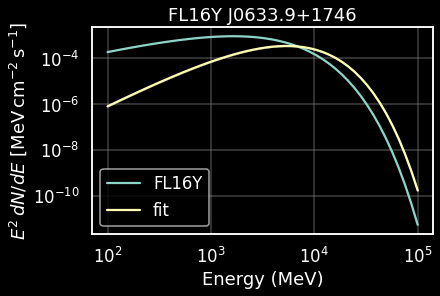

In [39]:
reload(main_mod)
FermiFit = main_mod.FermiFit
ff = FermiFit(pt)
src = roi_sources[0]
fig, ax = plt.subplots(figsize=(6,4))
src.sed_plot(ax=ax, label='FL16Y')

ff.summary()
    
with ff.preserve_parameters() as ctx:
    ff.fit()
    src.sed_plot(ax=ax, label='fit')
    new_flux_func = src.model.copy()
    ctx.restore = False
    
show(ff.fit_info)
ff.summary()

In [27]:
# --- Norm prof: fit only the normalization for each aenergy bin ---
# Group all bands by energy index (second element of band key); each group
# contains up to 4 PSF-type bands that share the same energy boundaries.


energy_indices = sorted({k[1] for k in pt.keys()})
src = ff.source_model[0] # the source we just fit above; should be the same as roi_sources[0]
flux_func = src.model.copy()
rows = []
with ff.preserve_parameters():
    for keys in pt.bands_by_energy.values():
        pt.select(keys=keys)
        ff.fit('_Norm')
        band0 = pt[keys[0]]
        e_mev = np.sqrt(band0.e0 * band0.e1).astype(int)
        x_fit  = ff.fit_info['x_fit'][0].round(3)
        sig    = ff.fit_info['sigs'][0].round(3)
        ts_val = ff.fit_info['ts_values'][0]
        rows.append(dict(e_mev=e_mev, x_fit=x_fit, sig=sig, 
                         ts=ts_val, sed=flux_func(e_mev)*e_mev**2))

pt.select()   # reset to all bands
prof = pd.DataFrame(rows)
show(prof)



,e_mev,x_fit,sig,ts,sed
0,133,-10.522,0.002,166520.5,1.465629e-06
1,237,-10.247,0.001,371415.1,4.883201e-06
2,421,-10.276,0.001,821869.7,1.517772e-05
3,749,-10.154,0.001,1205059.1,4.310900e-05
4,1333,-10.237,0.001,1467186.4,1.067313e-04
5,2371,-10.423,0.001,914458.0,2.153749e-04
6,4216,-10.266,0.002,486727.1,3.216826e-04
7,7498,-10.574,0.004,127434.9,3.082108e-04
8,13335,-10.859,0.010,15836.5,1.532029e-04
9,23713,-10.252,0.034,1200.6,2.889366e-05


LogNormProfile(flux=5.024e-11, errors=(2.12e-11, 1.203e-10), ts=9566.88)


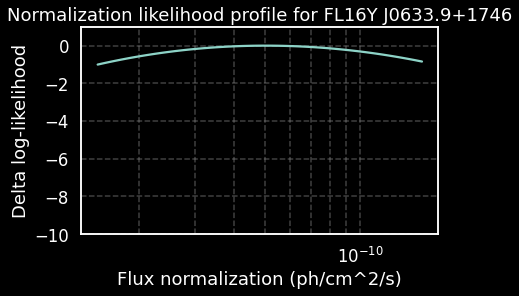

In [40]:
# for the selected source, return the normalization likelihood function in external units.
Lnorm = ff.norm_profile(src)
print(Lnorm)

pt.select()
lo, hi = Lnorm.errors
x = np.logspace(np.log10(max(lo * 0.7, 1e-12)), np.log10(hi * 1.3), 120)
y = Lnorm(x)

plt.figure(figsize=(6,4))
plt.plot(x, y - y.max())
plt.xscale('log')
plt.xlabel('Flux normalization (ph/cm^2/s)')
plt.ylabel('Delta log-likelihood')
plt.title(f'Normalization likelihood profile for {src.name}')
plt.ylim(-10, 1)
plt.grid(True, which='both', ls='--')
plt.show()

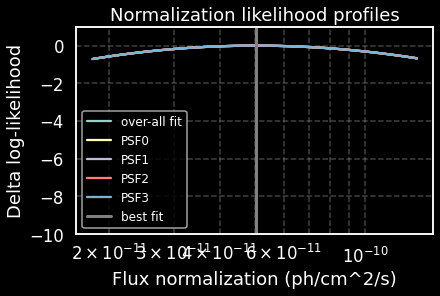

{(0, 4): Band(0, 4): PSF0@1.33 GeV nside 64 occ 1.001,
 (0, 5): Band(0, 5): PSF0@2.37 GeV nside 64 occ 1.000,
 (0, 6): Band(0, 6): PSF0@4.22 GeV nside 128 occ 0.918,
 (0, 7): Band(0, 7): PSF0@7.50 GeV nside 128 occ 0.735,
 (0, 8): Band(0, 8): PSF0@13.34 GeV nside 128 occ 0.498,
 (0, 9): Band(0, 9): PSF0@23.71 GeV nside 256 occ 0.092,
 (0, 10): Band(0, 10): PSF0@42.17 GeV nside 256 occ 0.044,
 (0, 11): Band(0, 11): PSF0@74.99 GeV nside 256 occ 0.020,
 (1, 2): Band(1, 2): PSF1@0.42 GeV nside 32 occ 1.000,
 (1, 3): Band(1, 3): PSF1@0.75 GeV nside 64 occ 1.000,
 (1, 4): Band(1, 4): PSF1@1.33 GeV nside 128 occ 0.999,
 (1, 5): Band(1, 5): PSF1@2.37 GeV nside 256 occ 0.760,
 (1, 6): Band(1, 6): PSF1@4.22 GeV nside 256 occ 0.541,
 (1, 7): Band(1, 7): PSF1@7.50 GeV nside 512 occ 0.118,
 (1, 8): Band(1, 8): PSF1@13.34 GeV nside 512 occ 0.055,
 (1, 9): Band(1, 9): PSF1@23.71 GeV nside 512 occ 0.024,
 (1, 10): Band(1, 10): PSF1@42.17 GeV nside 512 occ 0.011,
 (1, 11): Band(1, 11): PSF1@74.99 GeV n

In [41]:
plt.figure(figsize=(6,4))

norm_fit = Lnorm.flux
lo, hi = Lnorm.errors
x = np.logspace(np.log10(max(lo * 0.85, 1e-12)), np.log10(hi * 1.15), 120)

pt.select(emin=1000, emax=1200)
y = Lnorm(x)
plt.plot(x, y - y.max(), label='over-all fit')
plt.title('Normalization likelihood profiles')

for ie in range(4):
    pt.select((ie, 4))
    y = Lnorm(x)
    plt.plot(x, y - y.max(), label=f'PSF{ie}')

plt.gca().axvline(norm_fit, color='grey', ls='-', lw=3, label='best fit')
plt.xscale('log')
plt.xlabel('Flux normalization (ph/cm^2/s)')
plt.ylabel('Delta log-likelihood')
plt.ylim(-10, 1)
plt.grid(True, which='both', ls='--')
plt.legend(fontsize=12)
plt.show()
pt.select()

<utilities.ipynb_docgen.doc_formatter.<locals>.MimeBundleObject at 0x7b89c495bb20>
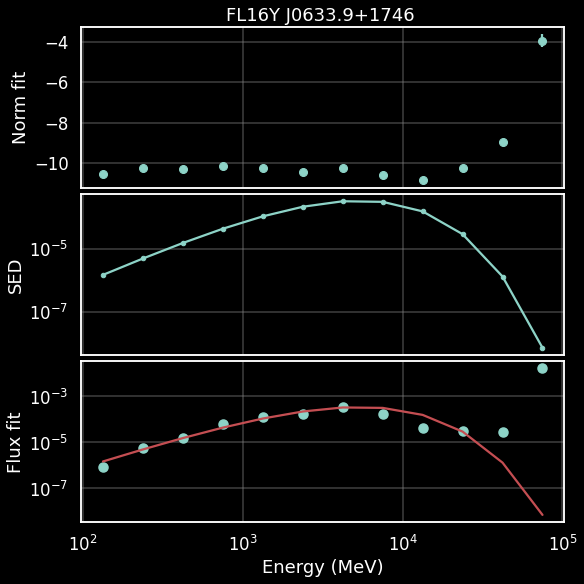

In [28]:
fig, axx = plt.subplots(3,1, figsize=(8,8), sharex=True)
ax,ax2,ax3 = axx
ax.errorbar(prof['e_mev'], prof['x_fit'], yerr=prof['sig'], fmt='o', markersize=8)
ax.set_xscale('log')
# ax2.set_xlabel('Energy (MeV)')
ax.set_ylabel('Norm fit')
ax.set_title(f'{selected_name} ')
e_mev = prof['e_mev']
ax2.plot(prof['e_mev'], prof['sed'], '.-', )#label='FL16Y SED')
# ax2.plot(prof['e_mev'], e_mev**2 * new_flux_func(e_mev), '+', label='Norm fit SED')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_ylabel('SED')#r'$E^2\,dN/dE\ [\mathrm{MeV\,cm^{-2}\,s^{-1}}]$')
# ax2.legend()
ax3.scatter(prof.e_mev, 10**prof.x_fit * prof.sed/flux_func['Norm'], )# label='flux fit')
ax3.plot(prof['e_mev'], e_mev**2 * new_flux_func(e_mev), 'r', label='Norm fit SED')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_ylabel('Flux fit')
ax3.set_xlabel('Energy (MeV)')
# ax3.legend()
show(fig)

In [26]:

# Table of norm_profile fits (Poisson.flux) divided by the overall-fit flux,
# for each individual band and for all PSF types combined at each energy.

overall_flux = Lnorm.flux
psf_types = sorted({k[0] for k in pt.keys()})

def _ratio_str(poiss, denom):
    """Return 'ratio ± half_err' or '< 95% limit' formatted string."""
    if poiss.flux <= 0:
        return f'< {poiss.limit / denom:.3f}'
    r = poiss.flux / denom
    lo, hi = poiss.errors
    err = (hi - lo) / (2.0 * denom)
    return f'{r:.3f} ± {err:.3f}'

def _safe_profile(keys_sel, tol=2.0):
    """Return norm_profile for the given selection, or None on failure."""
    pt.select(keys=keys_sel)
    try:
        return ff.norm_profile(src, tol=tol)
    except Exception:
        return None

rows = []
with ff.preserve_parameters():
    for e_idx, keys_e in pt.bands_by_energy.items():
        band0 = pt[keys_e[0]]
        e_mev = int(np.sqrt(band0.e0 * band0.e1))
        row = dict(e_mev=e_mev)

        # One norm_profile per individual band (PSF type)
        for key in keys_e:
            psf_idx = key[0]
            poiss = _safe_profile([key])
            row[f'PSF{psf_idx}'] = _ratio_str(poiss, overall_flux) if poiss else 'N/A'

        # norm_profile with all PSF types combined at this energy
        poiss_all = _safe_profile(keys_e)
        row['All'] = _ratio_str(poiss_all, overall_flux) if poiss_all else 'N/A'

        rows.append(row)

pt.select()
band_table = pd.DataFrame(rows).set_index('e_mev')['PSF0 PSF1 PSF2 PSF3 All'.split()]
show(band_table)


,PSF0,PSF1,PSF2,PSF3,All
e_mev,,,,,
133,NaN,NaN,0.626 ± 0.489,0.573 ± 0.536,0.598 ± 0.446
237,NaN,NaN,1.130 ± 1.070,1.123 ± 1.064,1.126 ± 1.083
421,NaN,0.541 ± 0.369,2.210 ± 2.050,2.200 ± 2.104,1.054 ± 0.805
749,NaN,1.062 ± 0.643,1.083 ± 0.957,4.197 ± 2.805,1.398 ± 1.088
1333,0.512 ± 0.353,1.955 ± 1.480,1.877 ± 1.618,8.075 ± 4.248,1.154 ± 1.281
2371,0.262 ± 0.196,3.860 ± 2.502,3.867 ± 2.935,15.728 ± 8.332,0.751 ± 0.722
4216,0.413 ± 0.244,1.854 ± 0.717,7.411 ± 1.488,7.550 ± 3.693,1.079 ± 0.885
7498,0.173 ± 0.003,3.818 ± 0.064,3.715 ± 0.066,3.511 ± 0.065,0.530 ± 0.304
13335,0.086 ± 0.004,2.061 ± 0.089,9.091 ± 0.401,7.802 ± 0.376,0.275 ± 0.006


In [29]:
rows = []
with ff.preserve_parameters():
    for e_idx, keys_e in pt.bands_by_energy.items():
        band0 = pt[keys_e[0]]
        e_mev = int(np.sqrt(band0.e0 * band0.e1))
        row = dict(e_mev=e_mev)

        # One norm_profile per individual band (PSF type)
        for key in keys_e:
            psf_idx = key[0]
            poiss = _safe_profile([key])
            row[f'PSF{psf_idx}'] = poiss# _ratio_str(poiss, overall_flux) if poiss else 'N/A'

        # norm_profile with all PSF types combined at this energy
        poiss_all = _safe_profile(keys_e)
        row['All'] = poiss_all #_ratio_str(poiss_all, overall_flux) if poiss_all else 'N/A'

        rows.append(row)

pt.select()
poiss_table = pd.DataFrame(rows).set_index('e_mev')['PSF0 PSF1 PSF2 PSF3 All'.split()]
show(poiss_table)

,PSF0,PSF1,PSF2,PSF3,All
e_mev,,,,,
133,NaN,NaN,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89be2864a0>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c0392b60>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c03913c0>
237,NaN,NaN,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c036abc0>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89bff602b0>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89bff616f0>
421,NaN,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89bff63040>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c49cddb0>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c49cdc00>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c49cd030>
749,NaN,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89bff78ac0>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89bff63c70>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89bff63070>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89bff61420>
1333,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c531aef0>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c351dea0>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89beb177c0>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c351cf70>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c351ecb0>
2371,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c11494e0>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89bff614e0>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89bff62800>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89bff60d90>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c0391ea0>
4216,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89be286560>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c036ae30>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89bff60190>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c5f21cf0>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c53197b0>
7498,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89beb17880>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c0393550>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c509cbb0>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89beb17f70>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c5318880>
13335,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89bff61600>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89bff608e0>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c0392500>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89c0392b90>,<like3.main.FermiFit.norm_profile.<locals>._LogNormProfile object at 0x7b89bffbc880>


In [30]:
t = poiss_table.iloc[11,0]; t.flux/overall_flux, np.array(t.errors)/overall_flux

(2253310.3684907965, array([ 669104.15975258, 7614071.88134296]))